# letra O

In [7]:
import pandas as pd

df = pd.read_csv('clientes.csv')
df = df[df['sigla'] == 'O'].copy()
print(f"Total clientes O: {len(df)}")
df.head()

Total clientes O: 69


,codcli,sigla,nome,cidade,estado,cd_tipocli,carteira,a_vl,a_cmv,a_mc,a_qtde,a_ped,d_vl,d_cmv,d_mc,d_qtde,d_ped
52,04586,O,RODA AUTO PECAS LTDA,JARDIM INGA BAIXO,GO,8.0,MAURICIO LIMA DA SILVA,130650.55,106438.46,11486.91,4728,337,49869.94,40506.63,4089.0,1716,136
98,07498,O,FLEX AUTO PECAS E MECANICA EIRELI ME,ALVORADA DO NORTE,GO,8.0,AUGUSTO RAFAEL SAMPAIO BONFIM,28880.15,22620.30,1733.01,797,25,8932.02,6603.39,592.8,242,8
468,16780,O,D2R AUTO PECAS E SERVICOS LTDA,LUZIANIA,GO,8.0,MICHAEL DOUGLAS LIMA DA SILVA,31627.36,22330.25,3855.81,1178,40,16491.36,12231.69,1322.6,400,10
906,23356,O,LUIZ AUTO PECAS LTDA,CRISTALINA,GO,8.0,ADALBERTO MIGUEL SOUZA,13734.35,10252.27,818.62,471,13,2763.69,1903.59,219.6,123,3
955,23729,O,RIBEIRO AUTO PECAS ACREUNA LTDA,ACREUNA,GO,8.0,FELIPE RIBEIRO DE JESUS,2349.15,1766.59,161.65,99,6,1454.70,1087.74,97.6,20,2


In [8]:
import json
with open('_config.json', 'r', encoding='utf-8') as f:
    cfg = json.load(f)

N_DIAS_A = int(cfg['n_dias_a'])
N_DIAS_D = int(cfg['n_dias_d'])

print(f"Período A: {cfg['periodo_a']} — {N_DIAS_A} dias úteis")
print(f"Período D: {cfg['periodo_d']} — {N_DIAS_D} dias úteis")

Período A: Jan-Mar 2026 — 61 dias úteis
Período D: Mai 01-29/2026 — 20 dias úteis


In [9]:
df['a_mc_d'] = df['a_mc'] / N_DIAS_A
df['d_mc_d'] = df['d_mc'] / N_DIAS_D
df['Δ MC/dia R$'] = df['d_mc_d'] - df['a_mc_d']

df_queda = df[df['Δ MC/dia R$'] < 0].copy()
df_queda = df_queda.sort_values('Δ MC/dia R$', ascending=True)

print(f"Total de clientes com queda: {len(df_queda)}")
print(f"Queda total de MC: R$ {df_queda['Δ MC/dia R$'].sum():.0f}/dia")
df_queda.head()

Total de clientes com queda: 29
Queda total de MC: R$ -544/dia


,codcli,sigla,nome,cidade,estado,cd_tipocli,carteira,a_vl,a_cmv,a_mc,a_qtde,a_ped,d_vl,d_cmv,d_mc,d_qtde,d_ped,a_mc_d,d_mc_d,Δ MC/dia R$
2920,I7267,O,TNET AUTO PECAS LTDA,GOIANIA - LESTE CIMA,GO,8.0,MANOEL MIGUEL NETO,47588.67,33186.00,6359.86,1241,83,0.00,0.00,0.0,0,0,104.26,0.00,-104.26
1961,I2933,O,ANA CRISTINA DE OLIVEIRA,GOIANESIA,GO,8.0,RAFAEL CAITANO CARDOSO,31240.06,21906.60,4363.94,502,35,1337.15,965.27,135.2,22,2,71.54,6.76,-64.78
1222,27408,O,KADOSH CENTRO AUTOMOTIVO LTDA,APARECIDA DE GOIANIA - SUL DIREITA,GO,8.0,VALQUISLEY SOUSA SILVA,46951.23,35708.66,4471.30,709,95,1989.10,1406.06,217.0,52,5,73.30,10.85,-62.45
1756,I1520,O,IOBERTO ALVES DOS SANTOS JUNIOR LTDA,NOVA VENEZA,GO,8.0,ADALBERTO MIGUEL SOUZA,26905.37,19313.86,3054.88,880,96,1500.58,944.47,310.2,52,10,50.08,15.51,-34.57
2603,I6087,O,KD AUTO PECAS LTDA,GOIANIA - 3KM CIMA,GO,8.0,AUGUSTO RAFAEL SAMPAIO BONFIM,27458.93,19247.75,3772.85,430,117,5935.12,4373.03,649.2,95,28,61.85,32.46,-29.39


In [ ]:
total_queda = df_queda['Δ MC/dia R$'].sum()
meta_80 = total_queda * 0.80

df_queda['queda_acum'] = df_queda['Δ MC/dia R$'].cumsum()
df_queda['pct_acum'] = df_queda['queda_acum'] / total_queda * 100

grupo_80 = df_queda[df_queda['pct_acum'] <= 80].copy()
grupo_20 = df_queda[df_queda['pct_acum'] > 80].copy()

print(f"Grupo 80%: {len(grupo_80)} clientes — R$ {grupo_80['Δ MC/dia R$'].sum():.0f}/dia de queda")
print(f"Grupo 20%: {len(grupo_20)} clientes — R$ {grupo_20['Δ MC/dia R$'].sum():.0f}/dia de queda")

print(f"Total queda: {total_queda:.0f}")

Grupo 80%: 11 clientes — R$ -428/dia de queda
Grupo 20%: 18 clientes — R$ -116/dia de queda
Total queda: -544

Grupo 80% — clientes prioritários:
codcli                                     nome  Δ MC/dia R$  pct_acum
 I7267                     TNET AUTO PECAS LTDA      -104.26 19.171080
 I2933                 ANA CRISTINA DE OLIVEIRA       -64.78 31.082671
 27408            KADOSH CENTRO AUTOMOTIVO LTDA       -62.45 42.565828
 I1520     IOBERTO ALVES DOS SANTOS JUNIOR LTDA       -34.57 48.922477
 I6087                       KD AUTO PECAS LTDA       -29.39 54.326640
 I1891                SMM PECAS E SERVICOS LTDA       -27.32 59.350177
 I2952 AUTO CARS EXPRESS CENTRO AUTOMOTIVO LTDA       -23.39 63.651074
 24237                   PACOTAO DAS PECAS LTDA       -23.38 67.950132
 I5887      ALLYF ANTONIO ALVES DOS SANTOS LTDA       -20.35 71.692042
 I1937                    OPEN AUTO CENTER LTDA       -19.52 75.281333
 I3959                      ALTERNATIVATEM LTDA       -18.91 78.758458


In [11]:
print(df_queda.columns.tolist())

['codcli', 'sigla', 'nome', 'cidade', 'estado', 'cd_tipocli', 'carteira', 'a_vl', 'a_cmv', 'a_mc', 'a_qtde', 'a_ped', 'd_vl', 'd_cmv', 'd_mc', 'd_qtde', 'd_ped', 'a_mc_d', 'd_mc_d', 'Δ MC/dia R$', 'queda_acum', 'pct_acum']


In [15]:
# Salvar os grupos
grupo_80.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_80_atencao_O.csv', index=False)
grupo_20.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_20_atencao_O.csv', index=False)

print("\nGrupo 80% — clientes prioritários:")
print(grupo_80[['codcli','nome','Δ MC/dia R$','pct_acum']].to_string(index=False))


Grupo 80% — clientes prioritários:
codcli                                     nome  Δ MC/dia R$  pct_acum
 I7267                     TNET AUTO PECAS LTDA      -104.26 19.171080
 I2933                 ANA CRISTINA DE OLIVEIRA       -64.78 31.082671
 27408            KADOSH CENTRO AUTOMOTIVO LTDA       -62.45 42.565828
 I1520     IOBERTO ALVES DOS SANTOS JUNIOR LTDA       -34.57 48.922477
 I6087                       KD AUTO PECAS LTDA       -29.39 54.326640
 I1891                SMM PECAS E SERVICOS LTDA       -27.32 59.350177
 I2952 AUTO CARS EXPRESS CENTRO AUTOMOTIVO LTDA       -23.39 63.651074
 24237                   PACOTAO DAS PECAS LTDA       -23.38 67.950132
 I5887      ALLYF ANTONIO ALVES DOS SANTOS LTDA       -20.35 71.692042
 I1937                    OPEN AUTO CENTER LTDA       -19.52 75.281333
 I3959                      ALTERNATIVATEM LTDA       -18.91 78.758458


In [16]:
# USANDO CLI_FORN
cf = pd.read_csv('cli_forn.csv')
cf['Δ vl_d'] = cf['d_vl_d'] - cf['a_vl_d']
cf['Δ vl_pct'] = (cf['Δ vl_d'] / cf['a_vl_d'].replace(0, float('nan'))) * 100

# Filtra só os 11 clientes do grupo 80%
codigos_80 = grupo_80['codcli'].astype(str).tolist()  # ← mudou aqui
cf_80 = cf[cf['codcli'].astype(str).isin(codigos_80)].copy()

print(f"Registros encontrados no cli_forn: {len(cf_80)}")
cf_80.head()

Registros encontrados no cli_forn: 578


,codcli,sigla,nome,codfor,fornecedor,fantasia,a_vl_d,a_cmv_d,a_mc_d,a_qtde,d_vl_d,d_cmv_d,d_mc_d,d_qtde,Δ vl_d,Δ vl_pct
1499,24237,O,PACOTAO DAS PECAS LTDA,2,3RHO INTERRUPTORES AUTOMOTIVOS LTDA,3RHO,0.84,0.60,0.15,1,5.47,4.02,0.84,2,4.63,551.190476
1500,24237,O,PACOTAO DAS PECAS LTDA,55,OSPINA IND DE AUTO PECAS LTDA,OSPINA,0.96,0.59,0.26,1,0.00,0.00,0.00,0,-0.96,-100.000000
1501,24237,O,PACOTAO DAS PECAS LTDA,76,EDANTI IND COM PECAS PARA AUTOS LTDA,EDANTI,0.21,0.12,0.07,2,0.00,0.00,0.00,0,-0.21,-100.000000
1502,24237,O,PACOTAO DAS PECAS LTDA,124,ZEN S.A INDUSTRIA METALURGICA,ZEN,39.01,28.90,5.95,49,28.49,20.96,3.68,10,-10.52,-26.967444
1503,24237,O,PACOTAO DAS PECAS LTDA,150,INDUSTRIA MARILIA DE AUTO PECAS S.A,MARILIA,12.46,8.56,2.50,11,1.21,0.76,0.30,1,-11.25,-90.288925


In [17]:
# Para cada cliente, calcula média e desvio padrão das quedas por fornecedor
resumo = []
for codcli, grupo in cf_80.groupby('codcli'):
    nome = grupo['nome'].iloc[0]
    
    # Só fornecedores que tinham venda antes
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    quedas = sub['Δ vl_pct'].dropna()
    
    if len(quedas) < 2:
        continue
    
    media = quedas.mean()
    desvio = quedas.std()
    cv = abs(desvio / media) if media != 0 else float('nan')
    n_fornecedores = len(sub)
    
    # Zeraram = só dos que tinham venda antes e agora estão em 0
    n_zerou = (sub['d_vl_d'] == 0).sum()
    
    resumo.append({
        'codcli': codcli,
        'Cliente': nome,
        'N fornecedores': n_fornecedores,
        'Queda média %': round(media, 1),
        'Desvio padrão': round(desvio, 1),
        'CV': round(cv, 2),
        'Zeraram': n_zerou,
        'Tipo': 'Normalizada' if cv < 0.5 else 'Concentrada'
    })

df_resumo = pd.DataFrame(resumo).sort_values('CV')
print(df_resumo.to_string(index=False))

codcli                                  Cliente  N fornecedores  Queda média %  Desvio padrão     CV  Zeraram        Tipo
 I1937                    OPEN AUTO CENTER LTDA              29         -100.0            0.0   0.00       29 Normalizada
 I7267                     TNET AUTO PECAS LTDA              75         -100.0            0.0   0.00       75 Normalizada
 27408            KADOSH CENTRO AUTOMOTIVO LTDA              54          -76.1           55.7   0.73       38 Concentrada
 I2933                 ANA CRISTINA DE OLIVEIRA              49          -80.7           63.3   0.78       42 Concentrada
 I1891                SMM PECAS E SERVICOS LTDA              49          -67.6           71.8   1.06       34 Concentrada
 I6087                       KD AUTO PECAS LTDA              47          -56.6           74.8   1.32       30 Concentrada
 I5887      ALLYF ANTONIO ALVES DOS SANTOS LTDA              51          -45.8           91.6   2.00       31 Concentrada
 I1520     IOBERTO ALVES

In [18]:
# Troca o código aqui para ver um cliente específico
# Deixa None para ver todos
FILTRO_CODCLI = '27408'

for codcli, grupo in cf_80.groupby('codcli'):
    if FILTRO_CODCLI and str(codcli) != str(FILTRO_CODCLI):
        continue
    nome = grupo['nome'].iloc[0]
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    sub = sub.sort_values('Δ vl_pct')
    
    print(f"\n{'='*60}")
    print(f"{nome} ({codcli})")
    print(f"Queda média: {sub['Δ vl_pct'].mean():.1f}% | Desvio: {sub['Δ vl_pct'].std():.1f} | CV: {abs(sub['Δ vl_pct'].std()/sub['Δ vl_pct'].mean()):.2f} | Fornecedores: {len(sub)}")
    print(f"{'Fornecedor':<25} {'Fat Antes':>12} {'Fat Atual':>12} {'Δ %':>10} {'Status'}")
    print('-'*70)
    for _, row in sub.iterrows():
        if row['d_vl_d'] == 0:
            status = '🔴 Zerou'
        elif row['a_vl_d'] == 0:
            status = '🆕 Novo'
        elif row['Δ vl_pct'] <= -10:
            status = '🟡 Caiu'
        elif row['Δ vl_pct'] >= 10:
            status = '🟢 Aumentou'
        else:
            status = '⚪ Estável'
        print(f"{str(row['fantasia']):<25} {row['a_vl_d']:>12.2f} {row['d_vl_d']:>12.2f} {row['Δ vl_pct']:>10.1f}% {status}")


KADOSH CENTRO AUTOMOTIVO LTDA (27408)
Queda média: -76.1% | Desvio: 55.7 | CV: 0.73 | Fornecedores: 54
Fornecedor                   Fat Antes    Fat Atual        Δ % Status
----------------------------------------------------------------------
3RHO                              2.28         0.00     -100.0% 🔴 Zerou
MTA                               1.53         0.00     -100.0% 🔴 Zerou
ROLTENS                           1.94         0.00     -100.0% 🔴 Zerou
BOSCH                            17.25         0.00     -100.0% 🔴 Zerou
SUN ELETRI                        2.44         0.00     -100.0% 🔴 Zerou
VALEO                             5.33         0.00     -100.0% 🔴 Zerou
RAINHA DA                         0.17         0.00     -100.0% 🔴 Zerou
FLORIO                            8.28         0.00     -100.0% 🔴 Zerou
TSA                               0.79         0.00     -100.0% 🔴 Zerou
RADNAQ                            0.70         0.00     -100.0% 🔴 Zerou
DPL                               2

In [19]:
with pd.ExcelWriter('analise_clientes_80_O.xlsx') as writer:
    # Aba resumo
    df_resumo.to_excel(writer, sheet_name='Resumo', index=False)
    
    # Uma aba por cliente
    for codcli, grupo in cf_80.groupby('codcli'):
        nome = grupo['nome'].iloc[0][:25]  # max 25 chars no nome da aba
        sub = grupo[grupo['a_vl_d'] > 0].copy()
        sub = sub.sort_values('Δ vl_pct')
        sub['Status'] = sub.apply(
            lambda r: 'Zerou' if r['d_vl_d'] == 0 else ('Novo' if r['a_vl_d'] == 0 else ''), axis=1
        )
        sub[['fantasia','a_vl_d','d_vl_d','Δ vl_pct','Status']].to_excel(
            writer, sheet_name=nome, index=False
        )

In [20]:
from collections import Counter

clientes_concentrados = df_resumo[df_resumo['Tipo'] == 'Concentrada']['codcli'].astype(str).tolist()

# Para cada cliente concentrado, pega os fornecedores que zeraram
fornecedores_zerados = {}
for cod in clientes_concentrados:
    sub = cf_80[cf_80['codcli'].astype(str) == cod].copy()
    zerados = sub[sub['d_vl_d'] == 0]['fantasia'].tolist()
    fornecedores_zerados[cod] = set(zerados)

# Conta em quantos clientes cada fornecedor aparece zerado
todos_zerados = [f for zerados in fornecedores_zerados.values() for f in zerados]
contagem = Counter(todos_zerados)

# Só os que aparecem em mais de 1 cliente
em_comum = {k: v for k, v in contagem.items() if v > 1}
df_comum = pd.DataFrame(em_comum.items(), columns=['Fornecedor', 'Qtd Clientes']).sort_values('Qtd Clientes', ascending=False)

C:\Users\priscila.marques\AppData\Local\Temp\ipykernel_21048\3275702067.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_forn, rotation=45, ha='right', fontsize=9)


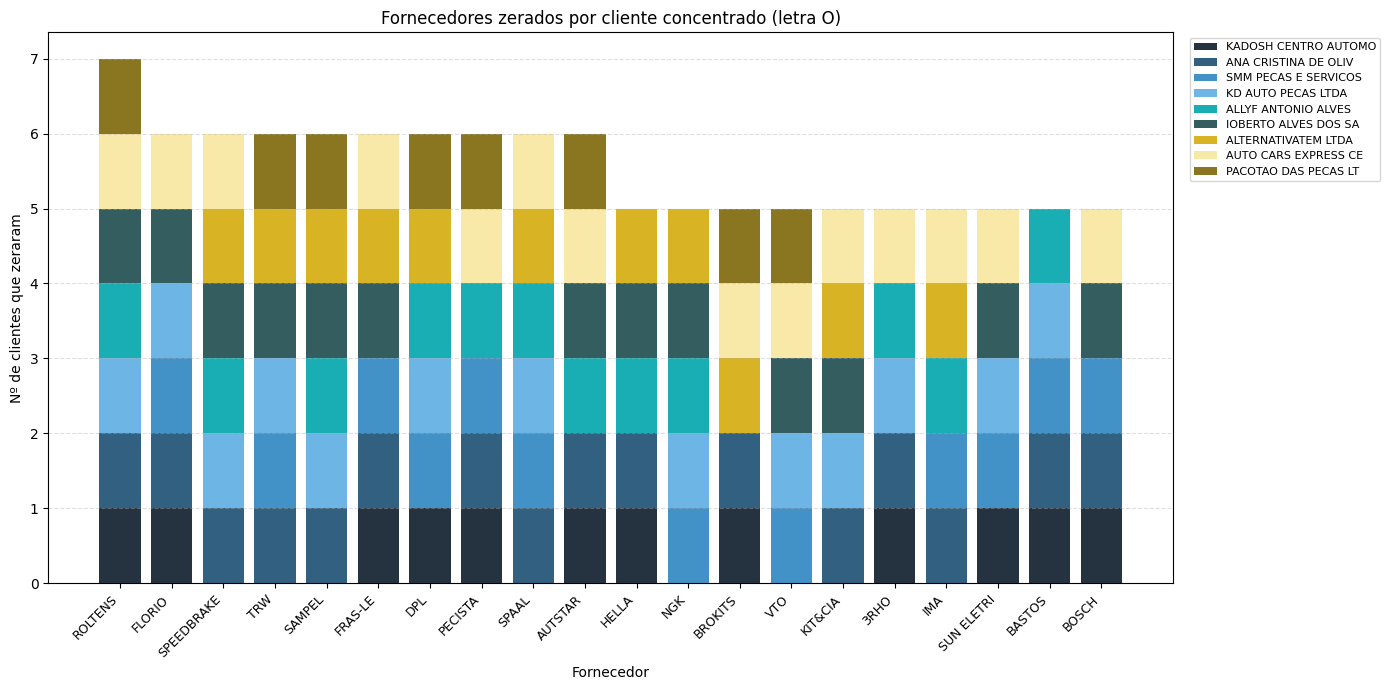

In [25]:
import matplotlib.pyplot as plt
import numpy as np

top_forn = df_comum.head(20)['Fornecedor'].tolist()

# Azuis e amarelos bem distintos
cores_lista = [
    '#0d1b2a',  # azul quase preto
    '#1b4f72',  # azul escuro
    '#2e86c1',  # azul médio
    '#5dade2',  # azul claro
    '#00a5ac',  # amarelo forte
    "#1d4b4d",  # amarelo alaranjado
    '#d4ac0d',  # amarelo dourado
    '#f9e79f',  # amarelo bem claro
    '#7d6608',  # amarelo escuro
]
cores_clientes = {cod: cor for cod, cor in zip(clientes_concentrados, cores_lista)}

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(top_forn))
for cod in clientes_concentrados:
    sub = cf_80[cf_80['codcli'].astype(str) == cod]
    nome = sub['nome'].iloc[0][:20]
    zerados = sub[sub['d_vl_d'] == 0]['fantasia'].tolist()
    valores = [1 if f in zerados else 0 for f in top_forn]
    
    ax.bar(top_forn, valores, bottom=bottom,
           color=cores_clientes[cod], label=nome, alpha=0.9)
    bottom += np.array(valores)

ax.set_xlabel("Fornecedor")
ax.set_ylabel("Nº de clientes que zeraram")
ax.set_title("Fornecedores zerados por cliente concentrado (letra O)", fontsize=12)
ax.set_xticklabels(top_forn, rotation=45, ha='right', fontsize=9)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('barras_fornecedores_clientes.png', dpi=150, bbox_inches='tight')
plt.show()

# Letra Q

In [26]:
import pandas as pd

df = pd.read_csv('clientes.csv')
df = df[df['sigla'] == 'Q'].copy()
print(f"Total clientes Q: {len(df)}")
df.head()

Total clientes Q: 19


,codcli,sigla,nome,cidade,estado,cd_tipocli,carteira,a_vl,a_cmv,a_mc,a_qtde,a_ped,d_vl,d_cmv,d_mc,d_qtde,d_ped
185,10537,Q,TOTAL AUTO PECAS EIRELI,NOVO GAMA,GO,8.0,VINICIUS GONCALVES MARTINS,23871.81,18828.41,3167.73,980,34,8157.95,6488.21,1344.8,483,20
1052,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,QUIRINOPOLIS,GO,8.0,FELIPE RIBEIRO DE JESUS,35230.49,25301.65,3383.67,1041,49,9522.97,6705.39,863.6,80,7
1258,27566,Q,WILMAR SOUSA DO NASCIMENTO ME,GOIANIA - 3KM CIMA,GO,8.0,MATHEUS RIBEIRO MIGUEL,11768.64,8038.70,469.09,671,20,449.41,300.99,21.6,25,3
1764,I1539,Q,DONIZETE MEIRA TEIXEIRA LTDA,JUSSARA,GO,8.0,MANOEL MIGUEL NETO,16790.97,12117.23,1381.04,945,27,6093.32,4331.39,455.2,241,7
1779,I1602,Q,BORGES OLIVEIRA PECAS PARA VEICULOS LTDA,CAMPINORTE,GO,8.0,MATHEUS RIBEIRO MIGUEL,10830.49,7371.64,1469.49,319,7,9190.02,6039.26,1299.4,241,11


In [27]:
import json
with open('_config.json', 'r', encoding='utf-8') as f:
    cfg = json.load(f)

N_DIAS_A = int(cfg['n_dias_a'])
N_DIAS_D = int(cfg['n_dias_d'])

print(f"Período A: {cfg['periodo_a']} — {N_DIAS_A} dias úteis")
print(f"Período D: {cfg['periodo_d']} — {N_DIAS_D} dias úteis")

Período A: Jan-Mar 2026 — 61 dias úteis
Período D: Mai 01-29/2026 — 20 dias úteis


In [28]:
df['a_mc_d'] = df['a_mc'] / N_DIAS_A
df['d_mc_d'] = df['d_mc'] / N_DIAS_D
df['Δ MC/dia R$'] = df['d_mc_d'] - df['a_mc_d']

df_queda = df[df['Δ MC/dia R$'] < 0].copy()
df_queda = df_queda.sort_values('Δ MC/dia R$', ascending=True)

print(f"Total de clientes com queda: {len(df_queda)}")
print(f"Queda total de MC: R$ {df_queda['Δ MC/dia R$'].sum():.0f}/dia")
df_queda.head()

Total de clientes com queda: 10
Queda total de MC: R$ -67/dia


,codcli,sigla,nome,cidade,estado,cd_tipocli,carteira,a_vl,a_cmv,a_mc,a_qtde,a_ped,d_vl,d_cmv,d_mc,d_qtde,d_ped,a_mc_d,d_mc_d,Δ MC/dia R$
1973,I2964,Q,GERLANDIA MARIA GOMES DA SILVA E CIA LTD,MOZARLANDIA,GO,8.0,MATHEUS RIBEIRO MIGUEL,12118.73,8242.80,1567.09,292,12,869.63,592.73,110.6,23,4,25.69,5.53,-20.16
1052,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,QUIRINOPOLIS,GO,8.0,FELIPE RIBEIRO DE JESUS,35230.49,25301.65,3383.67,1041,49,9522.97,6705.39,863.6,80,7,55.47,43.18,-12.29
1894,I2621,Q,SOPEL SO PECAS ELETRICAS LTDA,NIQUELANDIA,GO,8.0,MANOEL MIGUEL NETO,51978.60,38198.56,4514.61,2384,20,12086.75,8593.04,1301.8,275,10,74.01,65.09,-8.92
2179,I4352,Q,FARIAS AUTO CENTER LTDA,VIANOPOLIS,GO,8.0,KAIO VINICIUS VIEIRA DE JESUS,3056.90,2162.09,433.10,67,5,0.00,0.00,0.0,0,0,7.10,0.00,-7.10
1258,27566,Q,WILMAR SOUSA DO NASCIMENTO ME,GOIANIA - 3KM CIMA,GO,8.0,MATHEUS RIBEIRO MIGUEL,11768.64,8038.70,469.09,671,20,449.41,300.99,21.6,25,3,7.69,1.08,-6.61


In [29]:
total_queda = df_queda['Δ MC/dia R$'].sum()
meta_80 = total_queda * 0.80

df_queda['queda_acum'] = df_queda['Δ MC/dia R$'].cumsum()
df_queda['pct_acum'] = df_queda['queda_acum'] / total_queda * 100

grupo_80 = df_queda[df_queda['pct_acum'] <= 80].copy()
grupo_20 = df_queda[df_queda['pct_acum'] > 80].copy()

print(f"Grupo 80%: {len(grupo_80)} clientes — R$ {grupo_80['Δ MC/dia R$'].sum():.0f}/dia de queda")
print(f"Grupo 20%: {len(grupo_20)} clientes — R$ {grupo_20['Δ MC/dia R$'].sum():.0f}/dia de queda")

print(f"Total queda: {total_queda:.0f}")

Grupo 80%: 4 clientes — R$ -48/dia de queda
Grupo 20%: 6 clientes — R$ -19/dia de queda
Total queda: -67


In [30]:
# Salvar os grupos
grupo_80.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_80_atencao_Q.csv', index=False)
grupo_20.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_20_atencao_Q.csv', index=False)

print("\nGrupo 80% — clientes prioritários:")
print(grupo_80[['codcli','nome','Δ MC/dia R$','pct_acum']].to_string(index=False))


Grupo 80% — clientes prioritários:
codcli                                     nome  Δ MC/dia R$  pct_acum
 I2964 GERLANDIA MARIA GOMES DA SILVA E CIA LTD       -20.16 29.910979
 24165          AUTO ELETRICA QUIRINOPOLIS LTDA       -12.29 48.145401
 I2621            SOPEL SO PECAS ELETRICAS LTDA        -8.92 61.379822
 I4352                  FARIAS AUTO CENTER LTDA        -7.10 71.913947


In [31]:
# USANDO CLI_FORN
cf = pd.read_csv('cli_forn.csv')
cf['Δ vl_d'] = cf['d_vl_d'] - cf['a_vl_d']
cf['Δ vl_pct'] = (cf['Δ vl_d'] / cf['a_vl_d'].replace(0, float('nan'))) * 100

# Filtra só os 11 clientes do grupo 80%
codigos_80 = grupo_80['codcli'].astype(str).tolist()  # ← mudou aqui
cf_80 = cf[cf['codcli'].astype(str).isin(codigos_80)].copy()

print(f"Registros encontrados no cli_forn: {len(cf_80)}")
cf_80.head()

Registros encontrados no cli_forn: 139


,codcli,sigla,nome,codfor,fornecedor,fantasia,a_vl_d,a_cmv_d,a_mc_d,a_qtde,d_vl_d,d_cmv_d,d_mc_d,d_qtde,Δ vl_d,Δ vl_pct
1445,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,2,3RHO INTERRUPTORES AUTOMOTIVOS LTDA,3RHO,1.33,1.01,0.17,2,0.00,0.00,0.00,0,-1.33,-100.000000
1446,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,124,ZEN S.A INDUSTRIA METALURGICA,ZEN,45.50,36.35,2.64,34,97.03,71.90,5.07,12,51.53,113.252747
1447,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,150,INDUSTRIA MARILIA DE AUTO PECAS S.A,MARILIA,5.07,3.95,0.21,3,0.00,0.00,0.00,0,-5.07,-100.000000
1448,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,253,GATES DO BRASIL IND. E COMERCIO LTDA,GATES,18.60,13.10,3.18,7,0.00,0.00,0.00,0,-18.60,-100.000000
1449,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,254,UNIFAP INDUSTRIA METALURGICA LTDA,UNIFAP,7.60,5.68,0.18,20,38.88,27.26,2.58,7,31.28,411.578947


In [32]:
# Para cada cliente, calcula média e desvio padrão das quedas por fornecedor
resumo = []
for codcli, grupo in cf_80.groupby('codcli'):
    nome = grupo['nome'].iloc[0]
    
    # Só fornecedores que tinham venda antes
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    quedas = sub['Δ vl_pct'].dropna()
    
    if len(quedas) < 2:
        continue
    
    media = quedas.mean()
    desvio = quedas.std()
    cv = abs(desvio / media) if media != 0 else float('nan')
    n_fornecedores = len(sub)
    
    # Zeraram = só dos que tinham venda antes e agora estão em 0
    n_zerou = (sub['d_vl_d'] == 0).sum()
    
    resumo.append({
        'codcli': codcli,
        'Cliente': nome,
        'N fornecedores': n_fornecedores,
        'Queda média %': round(media, 1),
        'Desvio padrão': round(desvio, 1),
        'CV': round(cv, 2),
        'Zeraram': n_zerou,
        'Tipo': 'Normalizada' if cv < 0.5 else 'Concentrada'
    })

df_resumo = pd.DataFrame(resumo).sort_values('CV')
print(df_resumo.to_string(index=False))

codcli                                  Cliente  N fornecedores  Queda média %  Desvio padrão   CV  Zeraram        Tipo
 I4352                  FARIAS AUTO CENTER LTDA              14         -100.0            0.0 0.00       14 Normalizada
 I2621            SOPEL SO PECAS ELETRICAS LTDA              34          -64.7           47.9 0.74       17 Concentrada
 I2964 GERLANDIA MARIA GOMES DA SILVA E CIA LTD              33          -67.3          127.5 1.89       28 Concentrada
 24165          AUTO ELETRICA QUIRINOPOLIS LTDA              49          -27.9          255.2 9.15       38 Concentrada


In [36]:
# Troca o código aqui para ver um cliente específico
# Deixa None para ver todos
FILTRO_CODCLI = 'I4352'

for codcli, grupo in cf_80.groupby('codcli'):
    if FILTRO_CODCLI and str(codcli) != str(FILTRO_CODCLI):
        continue
    nome = grupo['nome'].iloc[0]
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    sub = sub.sort_values('Δ vl_pct')
    
    print(f"\n{'='*60}")
    print(f"{nome} ({codcli})")
    print(f"Queda média: {sub['Δ vl_pct'].mean():.1f}% | Desvio: {sub['Δ vl_pct'].std():.1f} | CV: {abs(sub['Δ vl_pct'].std()/sub['Δ vl_pct'].mean()):.2f} | Fornecedores: {len(sub)}")
    print(f"{'Fornecedor':<25} {'Fat Antes':>12} {'Fat Atual':>12} {'Δ %':>10} {'Status'}")
    print('-'*70)
    for _, row in sub.iterrows():
        if row['d_vl_d'] == 0:
            status = '🔴 Zerou'
        elif row['a_vl_d'] == 0:
            status = '🆕 Novo'
        elif row['Δ vl_pct'] <= -10:
            status = '🟡 Caiu'
        elif row['Δ vl_pct'] >= 10:
            status = '🟢 Aumentou'
        else:
            status = '⚪ Estável'
        print(f"{str(row['fantasia']):<25} {row['a_vl_d']:>12.2f} {row['d_vl_d']:>12.2f} {row['Δ vl_pct']:>10.1f}% {status}")


FARIAS AUTO CENTER LTDA (I4352)
Queda média: -100.0% | Desvio: 0.0 | CV: 0.00 | Fornecedores: 14
Fornecedor                   Fat Antes    Fat Atual        Δ % Status
----------------------------------------------------------------------
GATES                             1.52         0.00     -100.0% 🔴 Zerou
PERFECT                          16.34         0.00     -100.0% 🔴 Zerou
WEGA                              2.52         0.00     -100.0% 🔴 Zerou
HIPPER FRE                        1.56         0.00     -100.0% 🔴 Zerou
METAL LEVE                        0.90         0.00     -100.0% 🔴 Zerou
SAMPEL                            1.03         0.00     -100.0% 🔴 Zerou
OR PARTS                          5.01         0.00     -100.0% 🔴 Zerou
APLIC                             1.27         0.00     -100.0% 🔴 Zerou
SCHADEK                           2.65         0.00     -100.0% 🔴 Zerou
VOX                               0.92         0.00     -100.0% 🔴 Zerou
ROLTENS                           4.00   

In [37]:
with pd.ExcelWriter('analise_clientes_80_Q.xlsx') as writer:
    # Aba resumo
    df_resumo.to_excel(writer, sheet_name='Resumo', index=False)
    
    # Uma aba por cliente
    for codcli, grupo in cf_80.groupby('codcli'):
        nome = grupo['nome'].iloc[0][:25]  # max 25 chars no nome da aba
        sub = grupo[grupo['a_vl_d'] > 0].copy()
        sub = sub.sort_values('Δ vl_pct')
        sub['Status'] = sub.apply(
            lambda r: 'Zerou' if r['d_vl_d'] == 0 else ('Novo' if r['a_vl_d'] == 0 else ''), axis=1
        )
        sub[['fantasia','a_vl_d','d_vl_d','Δ vl_pct','Status']].to_excel(
            writer, sheet_name=nome, index=False
        )

In [38]:
from collections import Counter

clientes_concentrados = df_resumo[df_resumo['Tipo'] == 'Concentrada']['codcli'].astype(str).tolist()

# Para cada cliente concentrado, pega os fornecedores que zeraram
fornecedores_zerados = {}
for cod in clientes_concentrados:
    sub = cf_80[cf_80['codcli'].astype(str) == cod].copy()
    zerados = sub[sub['d_vl_d'] == 0]['fantasia'].tolist()
    fornecedores_zerados[cod] = set(zerados)

# Conta em quantos clientes cada fornecedor aparece zerado
todos_zerados = [f for zerados in fornecedores_zerados.values() for f in zerados]
contagem = Counter(todos_zerados)

# Só os que aparecem em mais de 1 cliente
em_comum = {k: v for k, v in contagem.items() if v > 1}
df_comum = pd.DataFrame(em_comum.items(), columns=['Fornecedor', 'Qtd Clientes']).sort_values('Qtd Clientes', ascending=False)

C:\Users\priscila.marques\AppData\Local\Temp\ipykernel_21048\3275702067.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_forn, rotation=45, ha='right', fontsize=9)


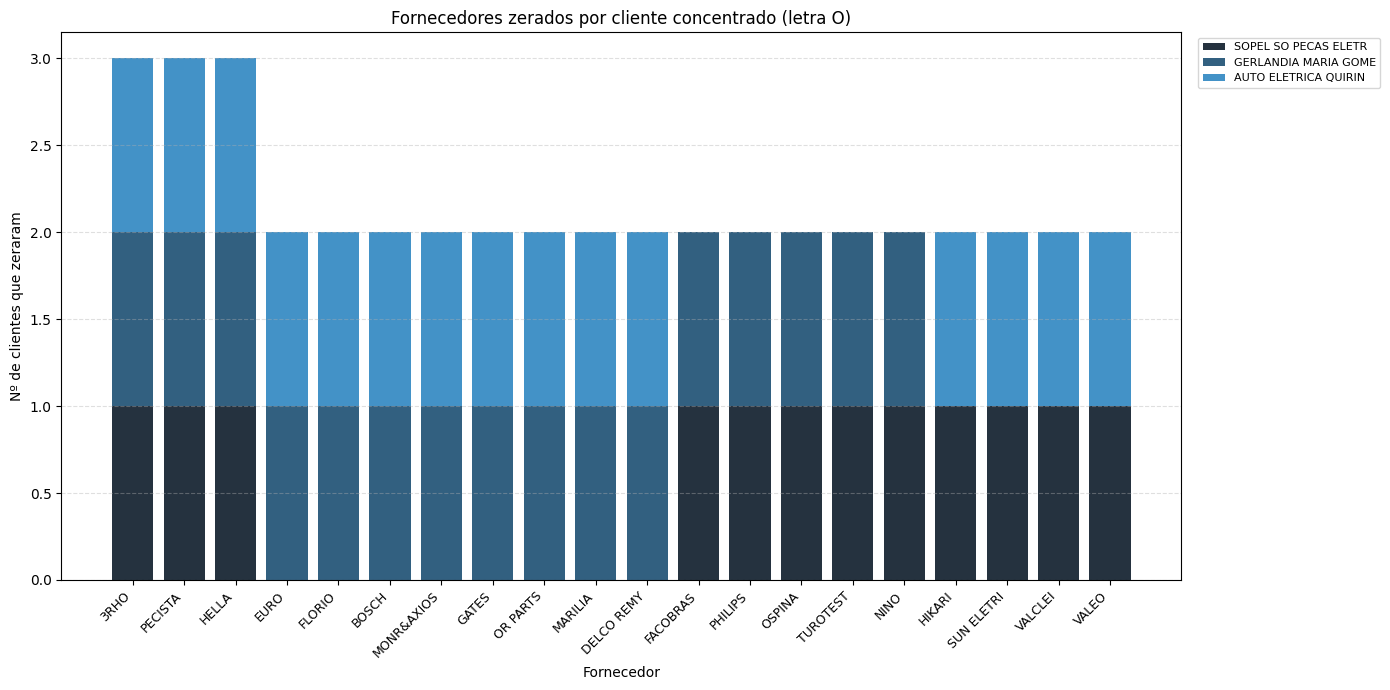

In [39]:
import matplotlib.pyplot as plt
import numpy as np

top_forn = df_comum.head(20)['Fornecedor'].tolist()

# Azuis e amarelos bem distintos
cores_lista = [
    '#0d1b2a',  # azul quase preto
    '#1b4f72',  # azul escuro
    '#2e86c1',  # azul médio
    '#5dade2',  # azul claro
    '#00a5ac',  # amarelo forte
    "#1d4b4d",  # amarelo alaranjado
    '#d4ac0d',  # amarelo dourado
    '#f9e79f',  # amarelo bem claro
    '#7d6608',  # amarelo escuro
]
cores_clientes = {cod: cor for cod, cor in zip(clientes_concentrados, cores_lista)}

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(top_forn))
for cod in clientes_concentrados:
    sub = cf_80[cf_80['codcli'].astype(str) == cod]
    nome = sub['nome'].iloc[0][:20]
    zerados = sub[sub['d_vl_d'] == 0]['fantasia'].tolist()
    valores = [1 if f in zerados else 0 for f in top_forn]
    
    ax.bar(top_forn, valores, bottom=bottom,
           color=cores_clientes[cod], label=nome, alpha=0.9)
    bottom += np.array(valores)

ax.set_xlabel("Fornecedor")
ax.set_ylabel("Nº de clientes que zeraram")
ax.set_title("Fornecedores zerados por cliente concentrado (letra O)", fontsize=12)
ax.set_xticklabels(top_forn, rotation=45, ha='right', fontsize=9)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('barras_fornecedores_clientes.png', dpi=150, bbox_inches='tight')
plt.show()